# Лабораторная работа №5 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б

#### Цель работы. Изучение ансамблей моделей машинного обучения.

## 1. Импорт библиотек и загрузка датасета

In [65]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from gmdhpy import gmdh

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


#### В качестве набора данных был выбран датасет про диабет. Целевая переменная - прогрессирование заболевания через год после baseline. Датасет содежит 10 признаков.

## 2. Проверка наличия пропусков и необходимости предобработки

In [67]:
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {list(X.columns)}")
print(f"Диапазон целевой переменной: [{y.min():.1f}, {y.max():.1f}]")

Количество образцов: 442
Количество признаков: 10
Признаки: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Диапазон целевой переменной: [25.0, 346.0]


#### Также этот набор я уже использовал и знаю, что там находятся только числовые признаки, выявлено также отсутствие пропусков. В дальнейшем проведём только масштабирование.

## 3. Анализ данных
### Распределение целевой переменной и корреляционная матрица

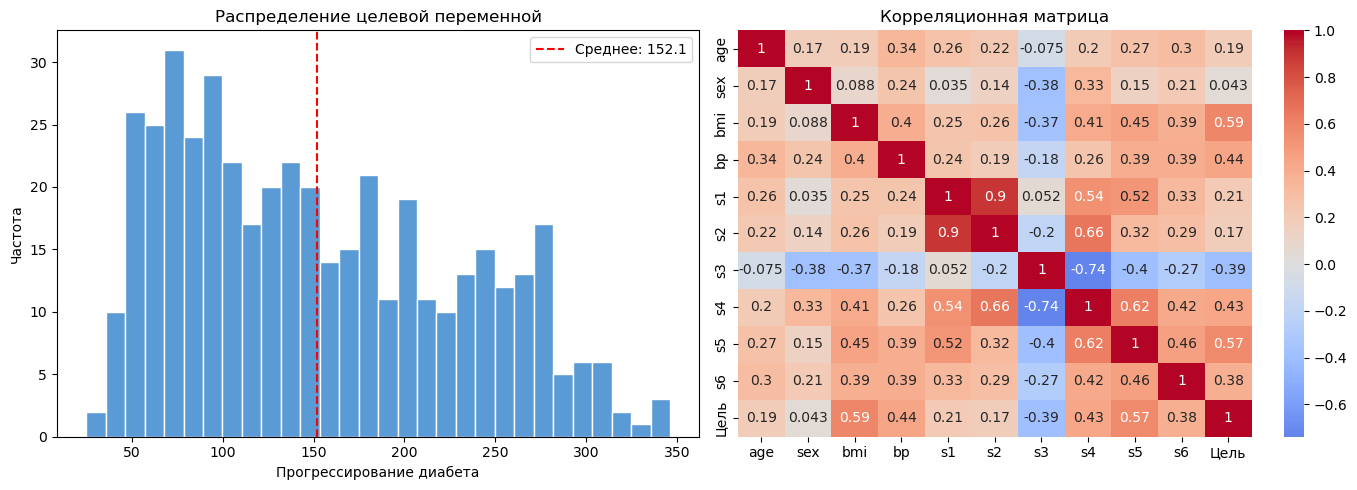

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=30, color='#5B9BD5', edgecolor='white')
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Прогрессирование диабета')
axes[0].set_ylabel('Частота')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Среднее: {y.mean():.1f}')
axes[0].legend()

corr_matrix = pd.DataFrame(np.column_stack([X, y]), columns=list(X.columns) + ['Цель']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

## 4. Масштабирование и разделение на общую и тестовую выборки

In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.0f}%)")

Обучающая выборка: 353 образцов (80%)
Тестовая выборка: 89 образцов (20%)


## 5. Обучение моделей и сравнение результатов

### Базовые модели
#### В качестве базовых моделей были выбраны: линейная регрессия, решающее дерево и случайный лес.

In [87]:
# Словарь для хранения результатов
results_mae = {}
results_full = {}

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ БАЗОВЫХ МОДЕЛЕЙ")
print("="*60)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Linear Regression - MAE: {mae_lr:.4f}")

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"Decision Tree - MAE: {mae_dt:.4f}")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest - MAE: {mae_rf:.4f}")


РЕЗУЛЬТАТЫ БАЗОВЫХ МОДЕЛЕЙ
Linear Regression - MAE: 42.7941
Decision Tree - MAE: 54.1573
Random Forest - MAE: 44.1733


### Стекинг

In [89]:
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СТЕКИНГА")
print("="*60)

base_models = [
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5
)
start_time = time.time()
stacking_reg.fit(X_train, y_train)
train_time_stacking = time.time() - start_time
y_pred_stacking = stacking_reg.predict(X_test)
mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
print(f"Время обучения: {train_time_stacking:.2f} сек, MAE: {mae_stacking:.4f}")


РЕЗУЛЬТАТЫ СТЕКИНГА
Время обучения: 0.69 сек, MAE: 42.8250


### Многослойный персептрон

In [90]:
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МНОГОСЛОЙНОГО ПЕРСЕПТРОНА")
print("="*60)

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
start_time = time.time()
mlp.fit(X_train, y_train)
train_time_mlp = time.time() - start_time
y_pred_mlp = mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
print(f"Время обучения: {train_time_mlp:.2f} сек, MAE: {mae_mlp:.4f}")


РЕЗУЛЬТАТЫ МНОГОСЛОЙНОГО ПЕРСЕПТРОНА
Время обучения: 0.54 сек, MAE: 42.7119


### МГУА

In [93]:
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МГУА")
print("="*60)

start_time = time.time()
combi_model = gmdh.MultilayerGMDH(ref_functions=gmdh.RefFunctionType.rfLinear)
combi_model.fit(X_train, y_train)
train_time_combi = time.time() - start_time
y_pred_combi = combi_model.predict(X_test)
mae_combi = mean_absolute_error(y_test, y_pred_combi)
print(f"Время обучения: {train_time_combi:.2f} сек, MAE: {mae_combi:.4f}")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МГУА MIA (НЕЛИНЕЙНЫЙ)")
print("="*60)
start_time = time.time()
mia_model = gmdh.MultilayerGMDH(ref_functions=(gmdh.RefFunctionType.rfLinearCov, gmdh.RefFunctionType.rfQuadratic, gmdh.RefFunctionType.rfCubic))
mia_model.fit(X_train, y_train)
train_time_mia = time.time() - start_time
y_pred_mia = mia_model.predict(X_test)
mae_mia = mean_absolute_error(y_test, y_pred_mia)
print(f"Время обучения: {train_time_mia:.2f} сек, MAE: {mae_mia:.4f}")


РЕЗУЛЬТАТЫ МГУА
train layer0 in 0.03 sec
train layer1 in 0.09 sec
train layer2 in 0.08 sec
train layer3 in 0.08 sec
train layer4 in 0.08 sec
train layer5 in 0.08 sec
train layer6 in 0.08 sec
Время обучения: 0.52 сек, MAE: 43.5022

РЕЗУЛЬТАТЫ МГУА MIA (НЕЛИНЕЙНЫЙ)
train layer0 in 0.09 sec
train layer1 in 0.35 sec
train layer2 in 0.34 sec
train layer3 in 0.34 sec
train layer4 in 0.34 sec
train layer5 in 0.34 sec
train layer6 in 0.34 sec
train layer7 in 0.34 sec
train layer8 in 0.47 sec
train layer9 in 0.35 sec
train layer10 in 0.35 sec
train layer11 in 0.35 sec
train layer12 in 0.35 sec
Время обучения: 4.38 сек, MAE: 41.7106


## 6. Итоговое сравнение качества

In [94]:
# Собираем все обученные модели в словарь
models = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Stacking': stacking_reg,
    'MLP': mlp
}
if GMDH_AVAILABLE:
    models['COMBI (GMDH)'] = combi_model
    models['MIA (GMDH)'] = mia_model

# Рассчет метрик
for name, model in models.items():
    y_pred = model.predict(X_test)
    results_full[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }

print("\n\n" + "="*70)
print("ИТОГОВОЕ СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ (НА ТЕСТОВОЙ ВЫБОРКЕ)")
print("="*70)
print(f"{'Модель':<25}{'MAE':<12}{'RMSE':<12}{'R²':<12}")
for name in models.keys():
    m = results_full[name]
    print(f"{name:<25}{m['MAE']:<12.4f}{m['RMSE']:<12.4f}{m['R²']:<12.4f}")

# Находим лучшие модели по каждой метрике
best_mae = min(results_full, key=lambda x: results_full[x]['MAE'])
best_rmse = min(results_full, key=lambda x: results_full[x]['RMSE'])
best_r2 = max(results_full, key=lambda x: results_full[x]['R²'])

print(f"\nЛучшая модель по MAE:  {best_mae} ({results_full[best_mae]['MAE']:.4f})")
print(f"Лучшая модель по RMSE: {best_rmse} ({results_full[best_rmse]['RMSE']:.4f})")
print(f"Лучшая модель по R²:   {best_r2} ({results_full[best_r2]['R²']:.4f})")



ИТОГОВОЕ СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ (НА ТЕСТОВОЙ ВЫБОРКЕ)
Модель                   MAE         RMSE        R²          
Linear Regression        42.7941     53.8534     0.4526      
Decision Tree            54.1573     69.9796     0.0757      
Random Forest            44.1733     54.4336     0.4407      
Stacking                 42.8250     53.1002     0.4678      
MLP                      42.7119     53.2983     0.4638      
COMBI (GMDH)             43.5022     53.6183     0.4574      
MIA (GMDH)               41.7106     52.3090     0.4836      

Лучшая модель по MAE:  MIA (GMDH) (41.7106)
Лучшая модель по RMSE: MIA (GMDH) (52.3090)
Лучшая модель по R²:   MIA (GMDH) (0.4836)


## 7. Визуализация результатов

### Гафик 1. Сравнение всех метрик

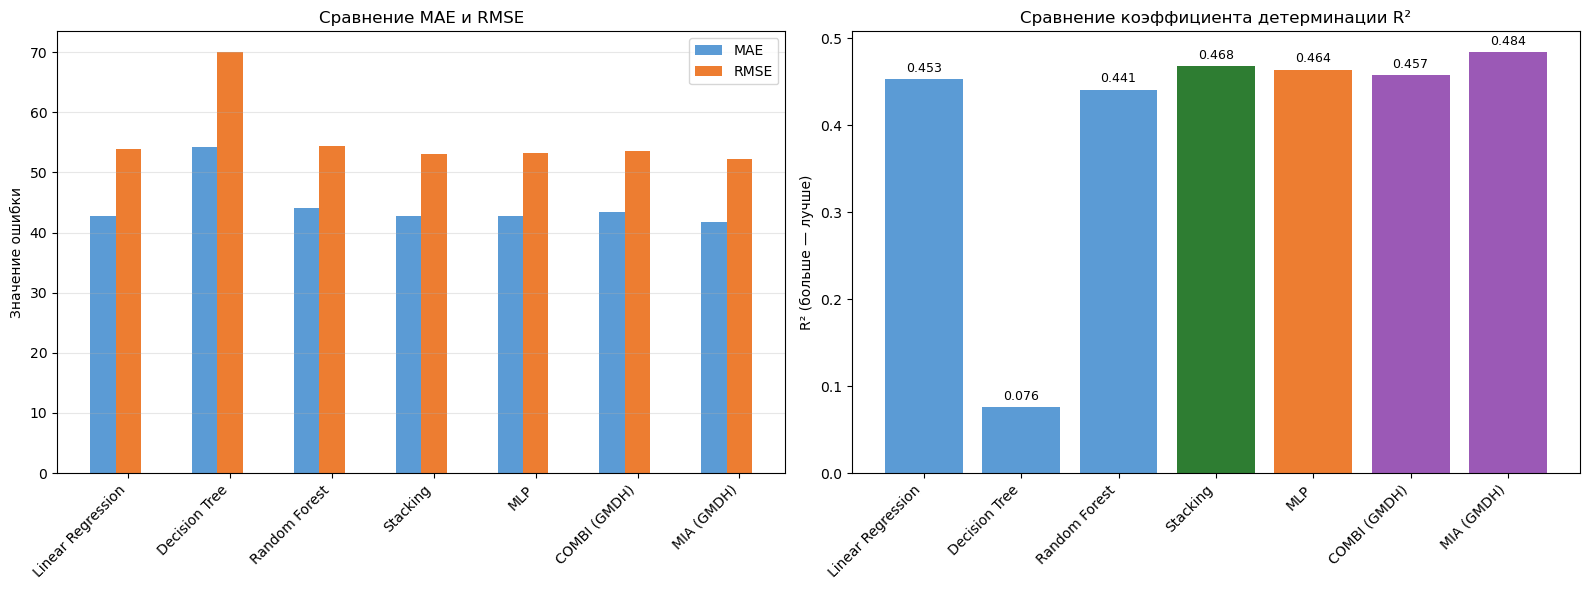

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(models.keys())
mae_vals = [results_full[m]['MAE'] for m in model_names]
rmse_vals = [results_full[m]['RMSE'] for m in model_names]
r2_vals = [results_full[m]['R²'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

axes[0].bar(x - width, mae_vals, width, label='MAE', color='#5B9BD5')
axes[0].bar(x, rmse_vals, width, label='RMSE', color='#ED7D31')
axes[0].set_ylabel('Значение ошибки')
axes[0].set_title('Сравнение MAE и RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# График 2: R² (больше — лучше)
bar_colors = []
for name in model_names:
    if name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
        bar_colors.append('#5B9BD5')
    elif name == 'Stacking':
        bar_colors.append('#2E7D32')
    elif name == 'MLP':
        bar_colors.append('#ED7D31')
    else:
        bar_colors.append('#9B59B6')

bars = axes[1].bar(model_names, r2_vals, color=bar_colors)
axes[1].set_ylabel('R² (больше — лучше)')
axes[1].set_title('Сравнение коэффициента детерминации R²')
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=45, ha='right')

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Диаграммы рассеяния для лучших моделей

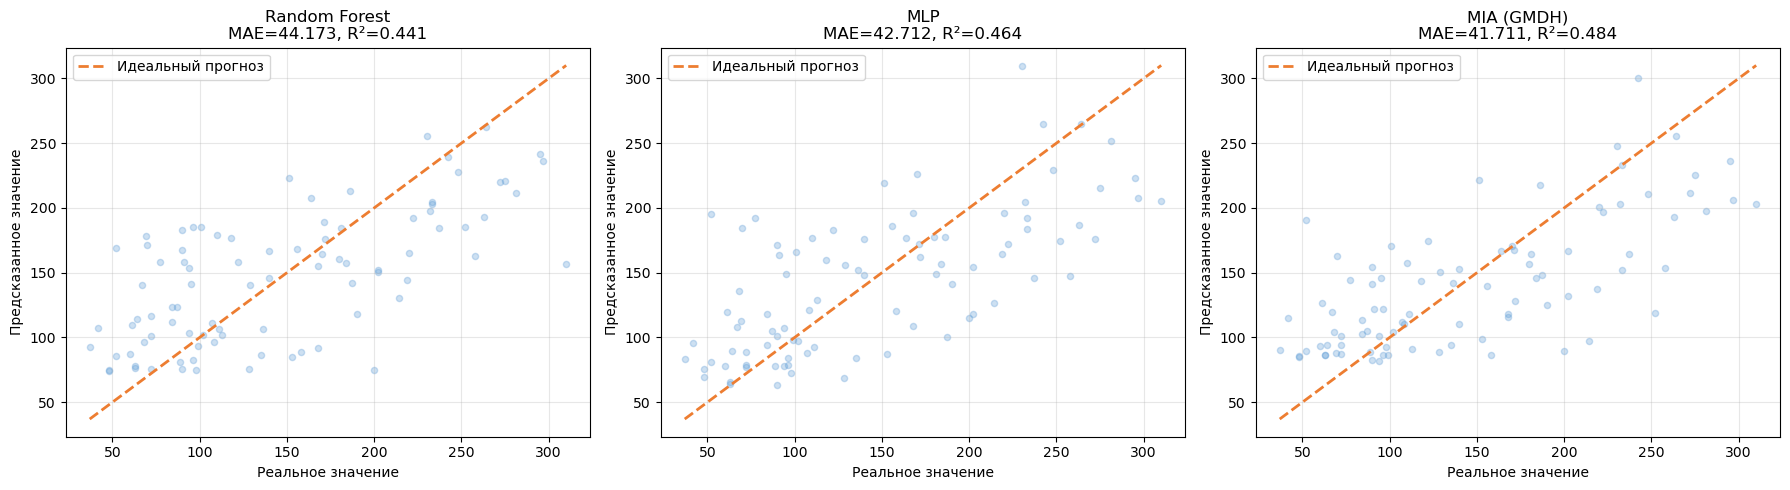

In [96]:
models_to_plot = {
    'Random Forest': rf,      # ключ должен совпадать с ключом в results_full
    'MLP': mlp,
    'MIA (GMDH)': mia_model   # если MIA была обучена и добавлена в models
}

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(18, 5))

for ax, (name, model) in zip(axes, models_to_plot.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, s=20, c='#5B9BD5')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            '--', color='#ED7D31', linewidth=2, label='Идеальный прогноз')
    ax.set_xlabel('Реальное значение')
    ax.set_ylabel('Предсказанное значение')
    # Теперь name точно есть в results_full
    ax.set_title(f'{name}\nMAE={results_full[name]["MAE"]:.3f}, R²={results_full[name]["R²"]:.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод
#### Лучшей моделью по всем метрикам (MAE, RMSE, R²) оказалась МГУА MIA. Это объясняется тем, что метод МГУА с нелинейными опорными функциями (квадратичными и кубическими) смог автоматически выявить сложные зависимости в данных, которые не уловили ни линейная регрессия, ни даже нейронная сеть MLP. При этом стекинг и MLP также показали высокое качество, близкое к лидеру, подтверждая эффективность ансамблевых методов и нейросетей. Дерево решений предсказуемо переобучилось, а случайный лес оказался чуть хуже линейных моделей, что говорит о том, что в данном датасете линейные и полиномиальные закономерности играют более важную роль, чем сложные взаимодействия признаков.